# Tax Compliance Risk Scoring: Production-Grade Revenue Analytics for Tax Administration

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Tax compliance risk assessment and audit prioritisation for revenue authorities

---

This notebook builds a production-oriented ML system for tax compliance risk scoring — the kind of analytics platform that supports the ATO's risk-differentiated approach to compliance. While using a general financial fraud dataset as a proxy, the framing targets Australian tax administration contexts.

**Why ML-assisted tax compliance matters:**
- The ATO collects ~$560 billion annually across 13+ million individual returns and 4+ million business returns
- The estimated tax gap is $33.5 billion (2021-22) — the difference between tax collected and tax theoretically owed
- Risk-differentiated compliance allocates limited audit resources to highest-risk taxpayers
- The ATO processes billions of data-matching records annually from employers, banks, share registries, and property transactions

**What makes tax compliance scoring different:**
- **Scale** — millions of returns, each with hundreds of data points
- **Data matching** — ATO receives third-party data (STP, banks, AIS) that can be cross-referenced against self-reported returns
- **Cost asymmetry** — auditing a compliant taxpayer wastes resources and damages trust; missing a non-compliant taxpayer costs revenue
- **Fairness** — the Taxpayers' Charter guarantees fair treatment; the Inspector-General of Taxation oversees ATO conduct
- **Legal framework** — Taxation Administration Act 1953, Income Tax Assessment Act 1997, Privacy Act 1988

**Notebook structure:**
1. Data Loading & Initial Assessment
2. Exploratory Data Analysis
3. Feature Engineering & Preprocessing
4. Compliance Risk Profile Analysis
5. Model Training & Comparison
6. Threshold Tuning & Cost-Sensitive Analysis
7. Model Interpretability & Fairness
8. Production Deployment Considerations
9. Key Takeaways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb
import os, time, warnings
warnings.filterwarnings('ignore')
from sklearn.base import clone

plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11})
COLOR_COMPLIANT = '#2ecc71'
COLOR_FRAUD = '#e74c3c'
print("Libraries loaded.")

Libraries loaded.


---
## 1. Data Loading & Initial Assessment

The dataset contains financial transaction records with customer profiles, transaction amounts, and fraud labels. In the ATO context, these map to:

| Dataset Feature | ATO Equivalent |
|----------------|----------------|
| Transaction amount | Declared income / deduction claim |
| Customer profile | Taxpayer profile (TFN, ABN, entity type) |
| Merchant category | Industry / occupation code (ANZSIC) |
| Transaction patterns | Lodgement history, amendment frequency |
| Fraud label | Non-compliance flag (audit outcome) |

In [2]:
# --- Data Loading: path discovery + load in ONE cell ---
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            candidate = os.path.join(root, f)
            # Pick the largest CSV if multiple
            if csv_path is None or os.path.getsize(candidate) > os.path.getsize(csv_path):
                csv_path = candidate

if csv_path is None:
    raise FileNotFoundError("No CSV found under /kaggle/input")

with open(csv_path, 'r') as fh:
    first_line = fh.readline()
sep = ';' if first_line.count(';') > first_line.count(',') else ','

df = pd.read_csv(csv_path, sep=sep)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded: /kaggle/input/datasets/amanalisiddiqui/fraud-detection-dataset/AIML Dataset.csv
Shape: 6,362,620 rows × 11 columns
Memory: 1523.1 MB


In [3]:
# Schema overview
print("=" * 70)
print("SCHEMA OVERVIEW")
print("=" * 70)
for col in df.columns:
    print(f"  {col:<35} {str(df[col].dtype):<10} unique={df[col].nunique():<10} nulls={df[col].isnull().sum()}")
print(f"\nTotal missing: {df.isnull().sum().sum()}")
df.head()

SCHEMA OVERVIEW
  step                                int64      unique=743        nulls=0
  type                                object     unique=5          nulls=0
  amount                              float64    unique=5316900    nulls=0
  nameOrig                            object     unique=6353307    nulls=0
  oldbalanceOrg                       float64    unique=1845844    nulls=0
  newbalanceOrig                      float64    unique=2682586    nulls=0
  nameDest                            object     unique=2722362    nulls=0
  oldbalanceDest                      float64    unique=3614697    nulls=0
  newbalanceDest                      float64    unique=3555499    nulls=0
  isFraud                             int64      unique=2          nulls=0
  isFlaggedFraud                      int64      unique=2          nulls=0

Total missing: 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Identify target column
target_col = None
for col in df.columns:
    col_lower = col.lower()
    if col_lower in ['fraud', 'is_fraud', 'isfraud', 'label', 'target', 'class']:
        target_col = col
        break
    if 'fraud' in col_lower:
        target_col = col
        break

if target_col is None:
    # Look for binary columns
    for col in df.columns:
        if df[col].nunique() == 2 and df[col].dtype in ['int64', 'float64']:
            if df[col].mean() < 0.5 and df[col].mean() > 0.001:
                target_col = col
                break

print(f"Target column: {target_col}")
print(f"Values: {df[target_col].value_counts().to_dict()}")

class_counts = df[target_col].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
majority_count = class_counts[majority_class]
minority_count = class_counts[minority_class]
fraud_pct = minority_count / len(df) * 100

print(f"\nCompliant ({majority_class}): {majority_count:,} ({majority_count/len(df)*100:.2f}%)")
print(f"Non-compliant ({minority_class}): {minority_count:,} ({fraud_pct:.2f}%)")
print(f"Ratio: 1:{majority_count/minority_count:.0f}")

print(f"\nATO context: The tax gap is ~5.6% of total theoretical liabilities.")
print(f"This dataset's non-compliance rate of {fraud_pct:.1f}% is used for ML training purposes.")

Target column: isFraud
Values: {0: 6354407, 1: 8213}

Compliant (0): 6,354,407 (99.87%)
Non-compliant (1): 8,213 (0.13%)
Ratio: 1:774

ATO context: The tax gap is ~5.6% of total theoretical liabilities.
This dataset's non-compliance rate of 0.1% is used for ML training purposes.


---
## 2. Exploratory Data Analysis

Tax compliance EDA mirrors the ATO's data-matching analytics — looking for discrepancies, outliers, and patterns that distinguish compliant from non-compliant taxpayers. The ATO's risk engines process billions of data points from Single Touch Payroll (STP), banks, property registries, and share registries to identify these patterns.

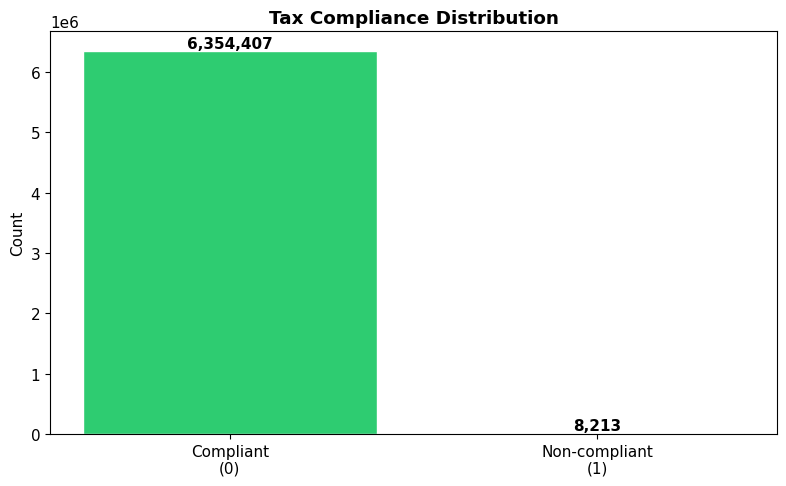

In [5]:
# 2.1 Class distribution
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([f'Compliant\n({majority_class})', f'Non-compliant\n({minority_class})'],
              [majority_count, minority_count], color=[COLOR_COMPLIANT, COLOR_FRAUD], edgecolor='white')
ax.set_title('Tax Compliance Distribution', fontweight='bold')
ax.set_ylabel('Count')
for bar, count in zip(bars, [majority_count, minority_count]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), 
            f'{count:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

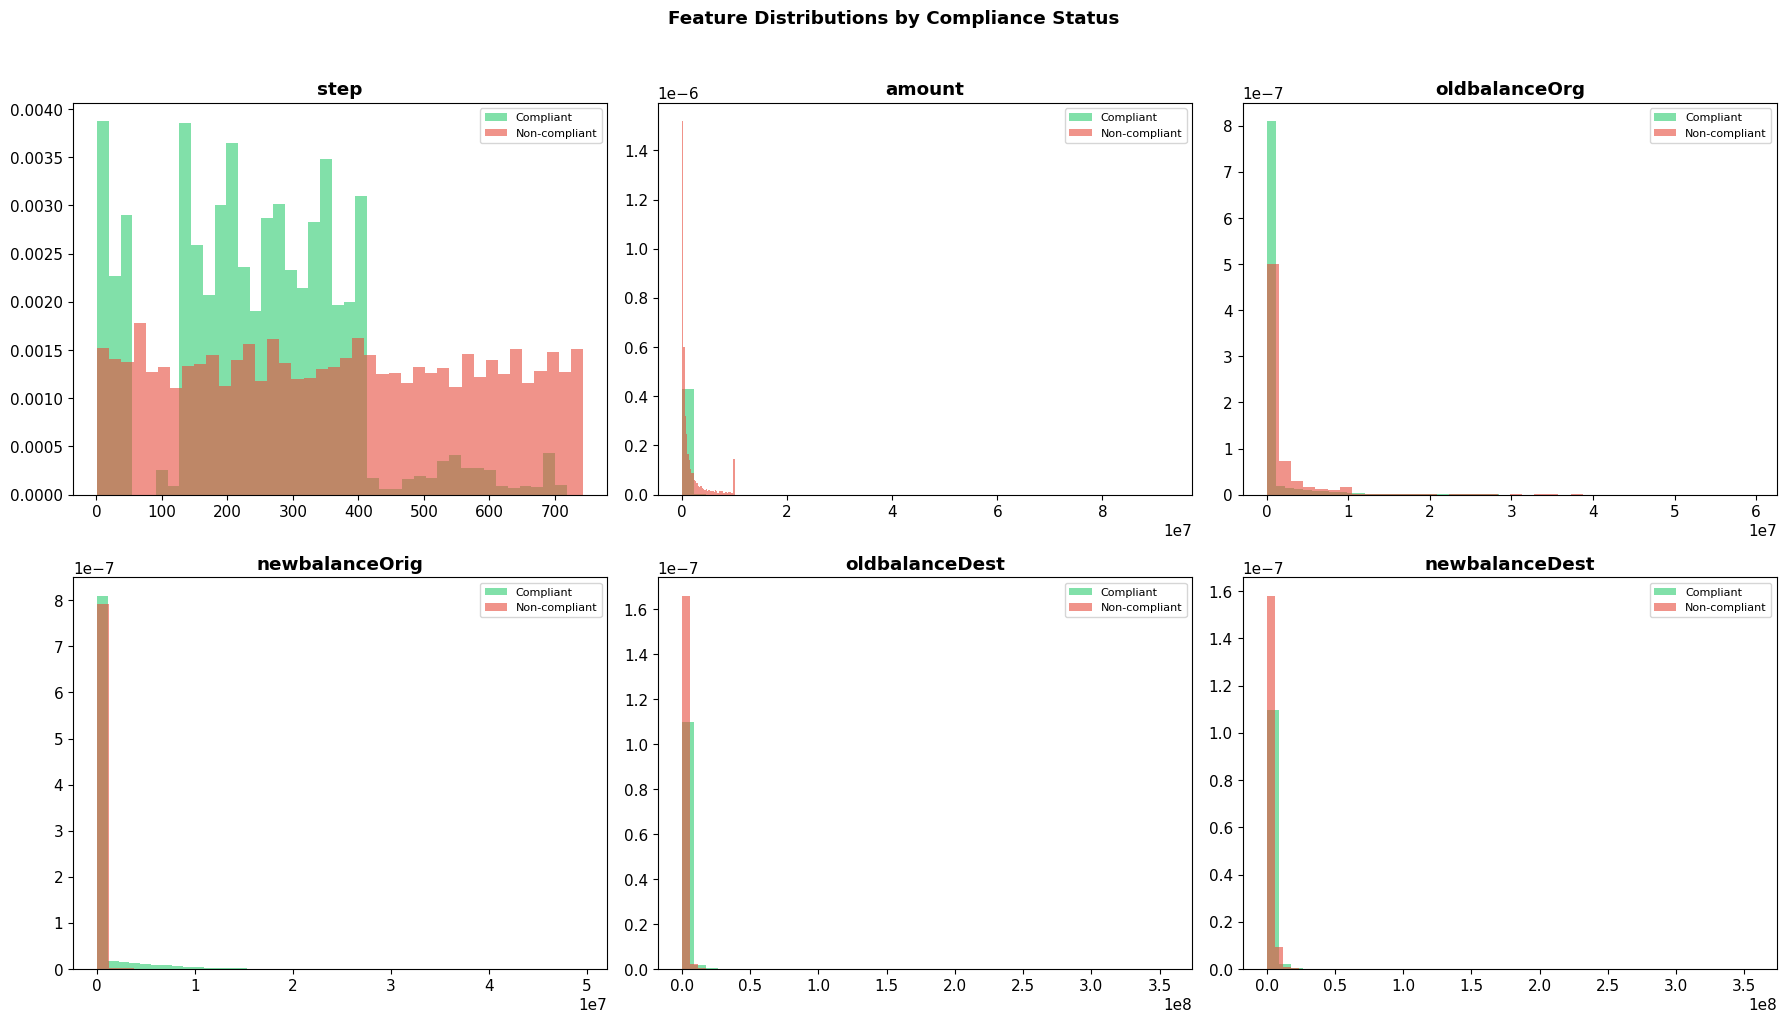

In [6]:
# 2.2 Numeric feature analysis
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col and df[c].nunique() > 2]
# Remove high-cardinality IDs
num_cols = [c for c in num_cols if df[c].nunique() < len(df) * 0.9]

n_plot = min(len(num_cols), 6)
if n_plot > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for idx, col in enumerate(num_cols[:n_plot]):
        ax = axes.flatten()[idx]
        for cls, color, label in [(majority_class, COLOR_COMPLIANT, 'Compliant'),
                                   (minority_class, COLOR_FRAUD, 'Non-compliant')]:
            subset = df[df[target_col] == cls][col].dropna()
            ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(col, fontweight='bold')
        ax.legend(fontsize=8)
    for idx in range(n_plot, 6):
        axes.flatten()[idx].set_visible(False)
    plt.suptitle('Feature Distributions by Compliance Status', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

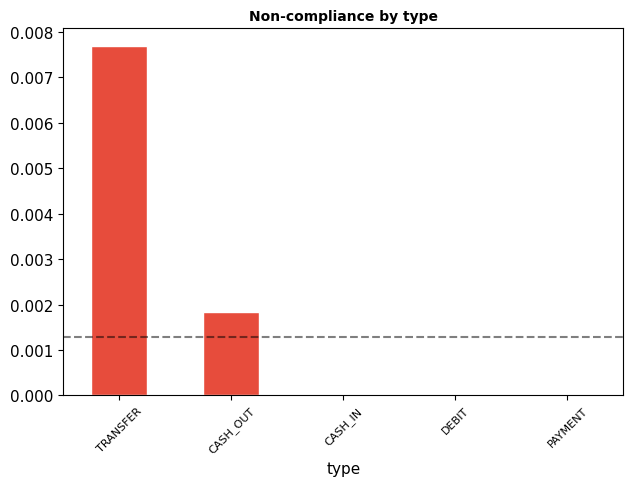

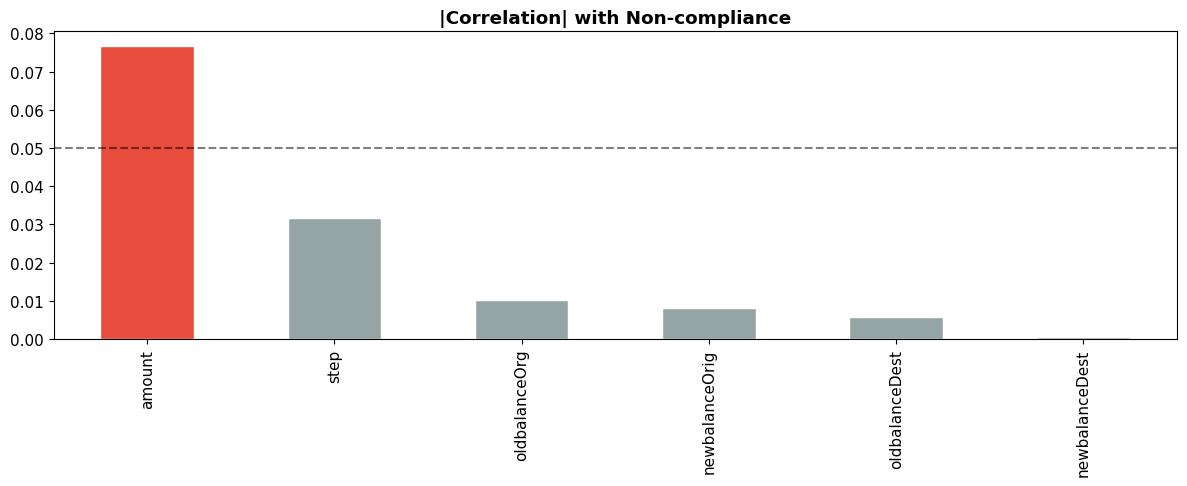

In [7]:
# 2.3 Categorical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col and df[c].nunique() <= 20]

n_cats = min(len(cat_cols), 6)
if n_cats > 0:
    rows = (n_cats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
    axes = np.array(axes).flatten()
    for idx, col in enumerate(cat_cols[:n_cats]):
        ax = axes[idx]
        fraud_rate = df.groupby(col)[target_col].apply(lambda x: (x == minority_class).mean()).sort_values(ascending=False)
        colors = [COLOR_FRAUD if r > fraud_pct/100 * 1.2 else COLOR_COMPLIANT for r in fraud_rate.values]
        fraud_rate.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'Non-compliance by {col}', fontweight='bold', fontsize=10)
        ax.axhline(y=fraud_pct/100, color='black', linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    for idx in range(n_cats, len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

# Correlation with target
if num_cols:
    target_binary = (df[target_col] == minority_class).astype(int)
    corr = df[num_cols].corrwith(target_binary).abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 5))
    colors_c = [COLOR_FRAUD if c > 0.05 else '#95a5a6' for c in corr.values]
    corr.plot(kind='bar', ax=ax, color=colors_c, edgecolor='white')
    ax.set_title('|Correlation| with Non-compliance', fontweight='bold')
    ax.axhline(y=0.05, color='black', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

---
## 3. Feature Engineering & Preprocessing

In ATO compliance analytics, feature engineering draws from:
- **Income discrepancy ratios** — self-reported vs third-party data
- **Deduction anomalies** — claims outside normal ranges for occupation/income bracket
- **Transaction patterns** — unusual volumes, amounts, or counterparties
- **Temporal patterns** — late lodgement, frequent amendments, seasonal anomalies
- **Entity relationships** — related-party transactions, trust distributions, corporate structures

In [8]:
# 3.1 Feature engineering
df_feat = df.copy()

# Drop ID-like columns
id_cols = [c for c in df_feat.columns if df_feat[c].nunique() > len(df_feat) * 0.8 
           and c != target_col and df_feat[c].dtype == 'object']
# Also drop any column named like an ID
id_cols += [c for c in df_feat.columns if any(kw in c.lower() for kw in ['_id', 'transaction_id', 'customer_id', 'account'])]
id_cols = list(set(id_cols))
df_feat.drop(columns=[c for c in id_cols if c in df_feat.columns], inplace=True, errors='ignore')
print(f"Dropped ID columns: {id_cols}")

# Log-transform monetary columns
money_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns 
              if any(kw in c.lower() for kw in ['amount', 'balance', 'income', 'salary', 'price', 'value'])]
for col in money_cols:
    if df_feat[col].min() >= 0:
        df_feat[f'{col}_log'] = np.log1p(df_feat[col])

# Amount-based ratios (if multiple amount columns exist)
amt_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns 
            if any(kw in c.lower() for kw in ['amount', 'balance'])]
if len(amt_cols) >= 2:
    df_feat['amount_ratio'] = df_feat[amt_cols[0]] / df_feat[amt_cols[1]].clip(lower=1)

# Encode categoricals
cat_feature_cols = [c for c in df_feat.select_dtypes(include=['object']).columns if c != target_col]
label_encoders = {}
for col in cat_feature_cols:
    le = LabelEncoder()
    df_feat[col + '_enc'] = le.fit_transform(df_feat[col].fillna('MISSING').astype(str))
    label_encoders[col] = le

new_features = [c for c in df_feat.columns if c not in df.columns]
print(f"Engineered {len(new_features)} new features")

Dropped ID columns: ['nameOrig']
Engineered 8 new features


In [9]:
# 3.2 Prepare feature matrix
drop_cols = [target_col] + cat_feature_cols
feature_cols = [c for c in df_feat.columns if c not in drop_cols
                and df_feat[c].dtype in ['int64', 'float64', 'int32', 'float32']]

df_feat[feature_cols] = df_feat[feature_cols].fillna(df_feat[feature_cols].median())
y_full = (df_feat[target_col] == minority_class).astype(int).values
X_full = StandardScaler().fit_transform(df_feat[feature_cols])

# Stratified sample to 100k if needed
SAMPLE_SIZE = 100_000
if len(X_full) > SAMPLE_SIZE:
    np.random.seed(42)
    fraud_idx = np.where(y_full == 1)[0]
    legit_idx = np.where(y_full == 0)[0]
    n_legit = SAMPLE_SIZE - len(fraud_idx)
    if n_legit < len(legit_idx):
        legit_sampled = np.random.choice(legit_idx, size=n_legit, replace=False)
    else:
        legit_sampled = legit_idx
    sample_idx = np.concatenate([fraud_idx, legit_sampled])
    np.random.shuffle(sample_idx)
    X = X_full[sample_idx]
    y = y_full[sample_idx]
    print(f"Sampled: {len(X):,} rows (all {len(fraud_idx):,} fraud + {len(legit_sampled):,} compliant)")
else:
    X = X_full
    y = y_full
    print(f"Using all {len(X):,} rows")

print(f"Shape: X={X.shape}, y={y.shape}")
print(f"Non-compliance rate: {y.mean()*100:.2f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

Sampled: 100,000 rows (all 8,213 fraud + 91,787 compliant)
Shape: X=(100000, 15), y=(100000,)
Non-compliance rate: 8.21%

Features (15):
  [ 0] step
  [ 1] amount
  [ 2] oldbalanceOrg
  [ 3] newbalanceOrig
  [ 4] oldbalanceDest
  [ 5] newbalanceDest
  [ 6] isFlaggedFraud
  [ 7] amount_log
  [ 8] oldbalanceOrg_log
  [ 9] newbalanceOrig_log
  [10] oldbalanceDest_log
  [11] newbalanceDest_log
  [12] amount_ratio
  [13] type_enc
  [14] nameDest_enc


---
## 4. Compliance Risk Profile Analysis

The ATO uses a risk-differentiated framework to categorise taxpayers. Understanding what drives non-compliance is essential for designing effective compliance strategies — from nudge letters (low risk) to full audit (high risk).

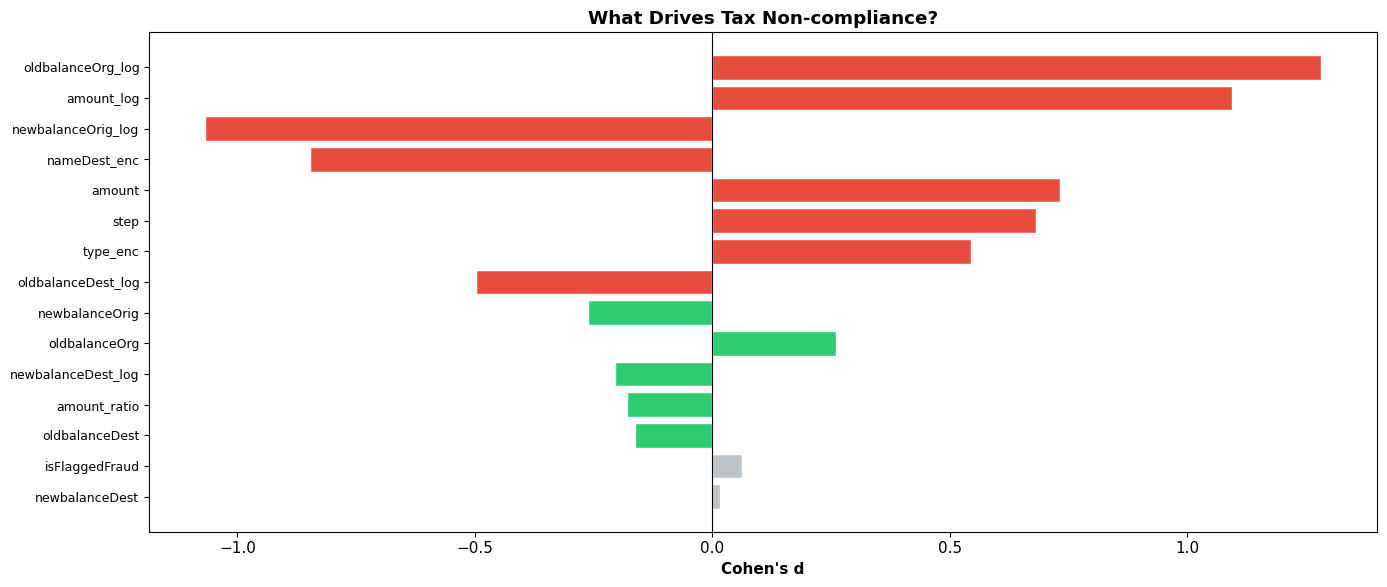

Top risk indicators:
  oldbalanceOrg_log                   d=+1.281
  amount_log                          d=+1.093
  newbalanceOrig_log                  d=-1.068
  nameDest_enc                        d=-0.848
  amount                              d=+0.732
  step                                d=+0.682
  type_enc                            d=+0.544
  oldbalanceDest_log                  d=-0.498


In [10]:
# 4.1 Cohen's d
cohens_d = {}
for i, col in enumerate(feature_cols):
    ok = X[y == 0, i]; fraud = X[y == 1, i]
    ps = np.sqrt((ok.std()**2 + fraud.std()**2) / 2)
    cohens_d[col] = (fraud.mean() - ok.mean()) / ps if ps > 0 else 0

sorted_effects = sorted(cohens_d.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(14, max(6, min(len(sorted_effects), 20) * 0.35)))
feats = [x[0] for x in sorted_effects[:20]]
vals = [x[1] for x in sorted_effects[:20]]
colors = [COLOR_FRAUD if abs(d) > 0.3 else COLOR_COMPLIANT if abs(d) > 0.15 else '#bdc3c7' for d in vals]
ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=9)
ax.set_xlabel("Cohen's d", fontweight='bold')
ax.set_title("What Drives Tax Non-compliance?", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top risk indicators:")
for f, d in sorted_effects[:8]:
    print(f"  {f:35s} d={d:+.3f}")

---
## 5. Model Training & Comparison

Four models with 3-fold CV. In ATO contexts, the model serves as a **risk scoring engine** that feeds into the compliance case selection process — it doesn't make audit decisions directly.

In [11]:
n_fraud = y.sum(); n_legit = (1-y).sum(); scale_ratio = n_legit / n_fraud

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=12),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_ratio, random_state=42, eval_metric='logloss', max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=-1, learning_rate=0.05, n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0)
}
print(f"Ratio: 1:{scale_ratio:.1f} | Samples: {len(X):,} | Features: {X.shape[1]}")

Ratio: 1:11.2 | Samples: 100,000 | Features: 15


In [12]:
# 5.2 CV
N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
results = {}; oof_preds = {}; oof_probs = {}

for mname, mtemplate in models.items():
    print(f"\n{'='*60}\nTraining: {mname}\n{'='*60}")
    oof_pred = np.zeros(len(y), dtype=int)
    oof_prob = np.zeros(len(y), dtype=float)
    t0 = time.time()
    for fold, (tri, vai) in enumerate(skf.split(X, y)):
        m = clone(mtemplate); m.fit(X[tri], y[tri])
        oof_pred[vai] = m.predict(X[vai])
        oof_prob[vai] = m.predict_proba(X[vai])[:, 1]
        print(f"  Fold {fold+1}: F1={f1_score(y[vai], oof_pred[vai]):.4f} | "
              f"PR-AUC={average_precision_score(y[vai], oof_prob[vai]):.4f} | "
              f"ROC-AUC={roc_auc_score(y[vai], oof_prob[vai]):.4f}")
    elapsed = time.time() - t0
    results[mname] = {
        'accuracy': accuracy_score(y, oof_pred), 'precision': precision_score(y, oof_pred, zero_division=0),
        'recall': recall_score(y, oof_pred, zero_division=0), 'f1': f1_score(y, oof_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, oof_prob), 'pr_auc': average_precision_score(y, oof_prob),
        'brier': brier_score_loss(y, oof_prob), 'time': elapsed
    }
    oof_preds[mname] = oof_pred; oof_probs[mname] = oof_prob
    r = results[mname]
    print(f"  OOF: F1={r['f1']:.4f} | PR-AUC={r['pr_auc']:.4f} | ROC-AUC={r['roc_auc']:.4f}")


Training: Logistic Regression
  Fold 1: F1=0.8204 | PR-AUC=0.9804 | ROC-AUC=0.9959
  Fold 2: F1=0.8186 | PR-AUC=0.9814 | ROC-AUC=0.9957
  Fold 3: F1=0.8283 | PR-AUC=0.9814 | ROC-AUC=0.9960
  OOF: F1=0.8224 | PR-AUC=0.9811 | ROC-AUC=0.9959

Training: Random Forest
  Fold 1: F1=0.9976 | PR-AUC=0.9984 | ROC-AUC=0.9990
  Fold 2: F1=0.9976 | PR-AUC=0.9983 | ROC-AUC=0.9990
  Fold 3: F1=0.9980 | PR-AUC=0.9989 | ROC-AUC=0.9996
  OOF: F1=0.9977 | PR-AUC=0.9985 | ROC-AUC=0.9992

Training: XGBoost
  Fold 1: F1=0.9900 | PR-AUC=0.9982 | ROC-AUC=0.9996
  Fold 2: F1=0.9953 | PR-AUC=0.9985 | ROC-AUC=0.9997
  Fold 3: F1=0.9963 | PR-AUC=0.9987 | ROC-AUC=0.9997
  OOF: F1=0.9939 | PR-AUC=0.9985 | ROC-AUC=0.9997

Training: LightGBM
  Fold 1: F1=0.9971 | PR-AUC=0.9986 | ROC-AUC=0.9995
  Fold 2: F1=0.9982 | PR-AUC=0.9989 | ROC-AUC=0.9997
  Fold 3: F1=0.9974 | PR-AUC=0.9987 | ROC-AUC=0.9997
  OOF: F1=0.9976 | PR-AUC=0.9988 | ROC-AUC=0.9996


In [13]:
# Results table
print("\n" + "=" * 95)
print("MODEL COMPARISON")
print("=" * 95)
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'ROC':>7} {'PR-AUC':>7} {'Brier':>7}")
print("-" * 95)
for n, r in results.items():
    print(f"{n:<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} "
          f"{r['f1']:>7.4f} {r['roc_auc']:>7.4f} {r['pr_auc']:>7.4f} {r['brier']:>7.4f}")
best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])
print(f"\nBest by PR-AUC: {best_model[0]} ({best_model[1]['pr_auc']:.4f})")


MODEL COMPARISON
Model                      Acc    Prec  Recall      F1     ROC  PR-AUC   Brier
-----------------------------------------------------------------------------------------------
Logistic Regression     0.9647  0.7005  0.9957  0.8224  0.9959  0.9811  0.0236
Random Forest           0.9996  0.9991  0.9963  0.9977  0.9992  0.9985  0.0004
XGBoost                 0.9990  0.9910  0.9967  0.9939  0.9997  0.9985  0.0010
LightGBM                0.9996  0.9990  0.9961  0.9976  0.9996  0.9988  0.0004

Best by PR-AUC: LightGBM (0.9988)


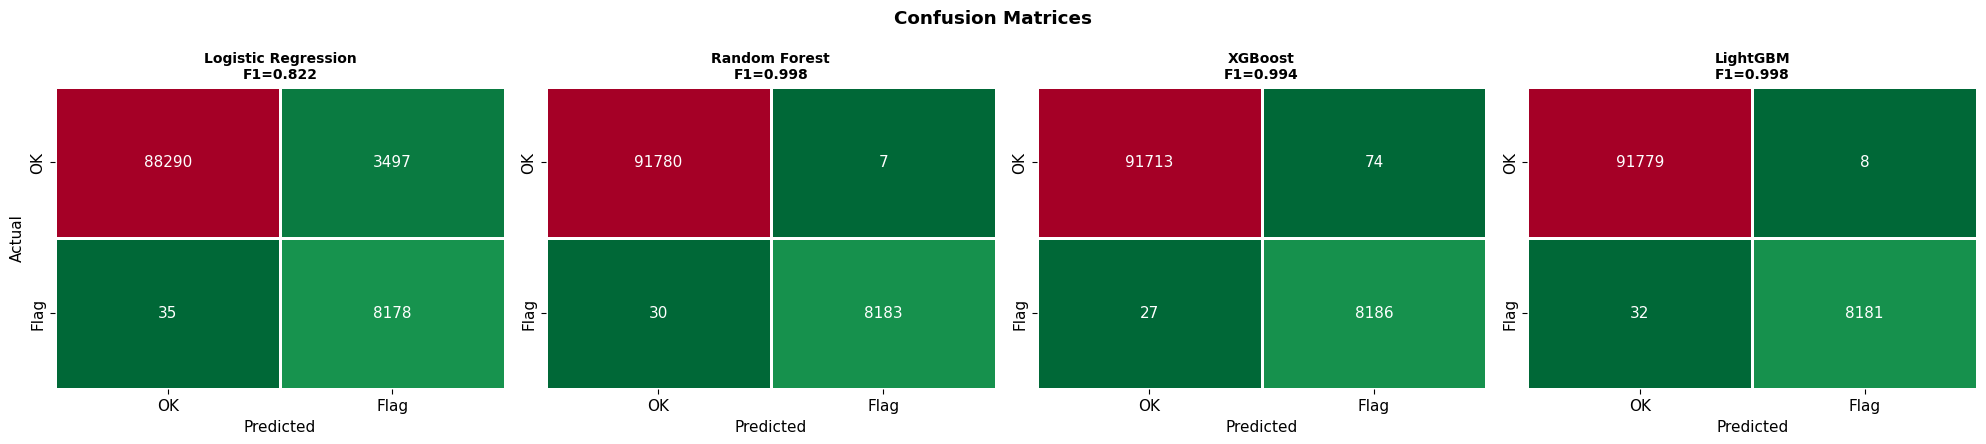

In [14]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, (n, pred) in enumerate(oof_preds.items()):
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
                xticklabels=['OK', 'Flag'], yticklabels=['OK', 'Flag'], cbar=False, linewidths=1)
    axes[idx].set_title(f'{n}\nF1={results[n]["f1"]:.3f}', fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Actual' if idx == 0 else ''); axes[idx].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout()
plt.show()

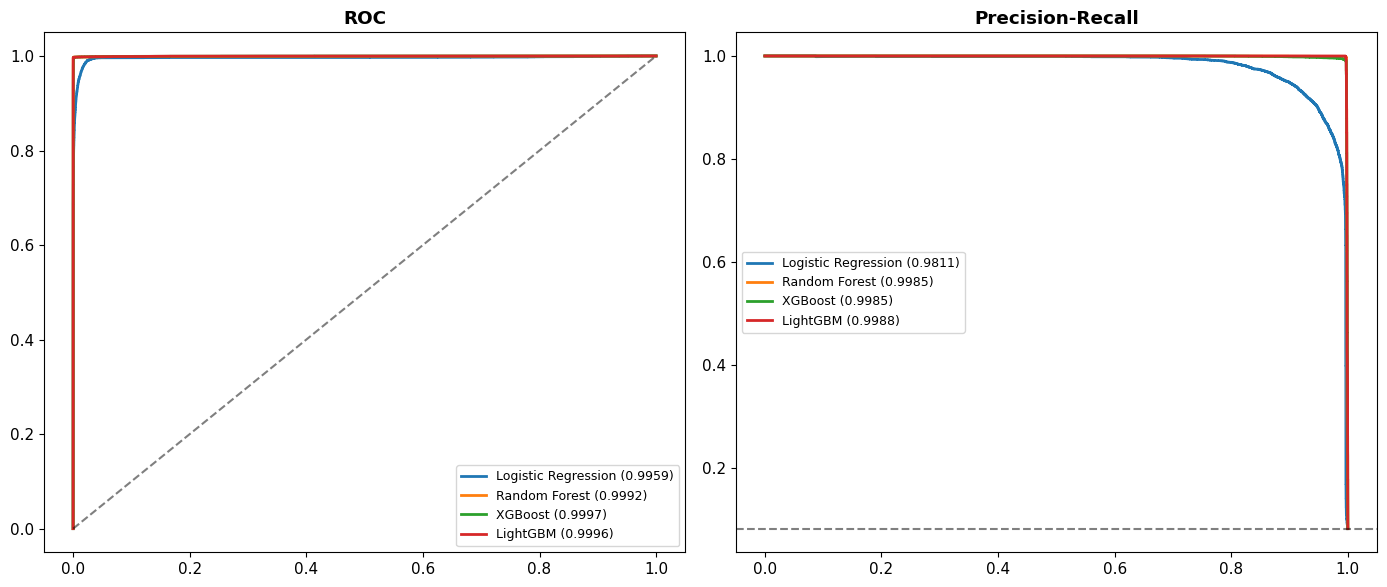

In [15]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for n, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, prob)
    axes[0].plot(fpr, tpr, label=f"{n} ({results[n]['roc_auc']:.4f})", linewidth=2)
    prec, rec, _ = precision_recall_curve(y, prob)
    axes[1].plot(rec, prec, label=f"{n} ({results[n]['pr_auc']:.4f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC', fontweight='bold'); axes[0].legend(fontsize=9)
axes[1].axhline(y=y.mean(), color='k', linestyle='--', alpha=0.5)
axes[1].set_title('Precision-Recall', fontweight='bold'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

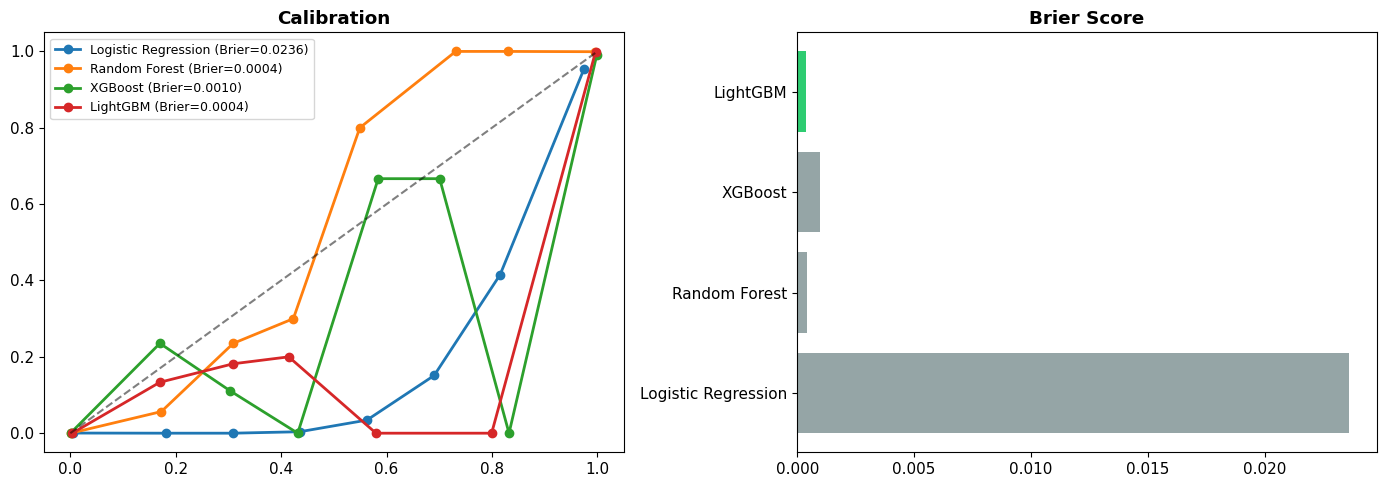

In [16]:
# Calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n, prob in oof_probs.items():
    pt, pp = calibration_curve(y, prob, n_bins=8, strategy='uniform')
    axes[0].plot(pp, pt, marker='o', label=f"{n} (Brier={results[n]['brier']:.4f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5); axes[0].set_title('Calibration', fontweight='bold'); axes[0].legend(fontsize=9)
brier = [results[n]['brier'] for n in results]
axes[1].barh(list(results.keys()), brier, color=[COLOR_COMPLIANT if b == min(brier) else '#95a5a6' for b in brier])
axes[1].set_title('Brier Score', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Threshold Tuning & Cost-Sensitive Analysis

The ATO uses a risk-differentiated approach with multiple compliance treatments:

| Risk Tier | ATO Action | Threshold Equivalent |
|-----------|-----------|---------------------|
| **Very Low** | No action, pre-fill assists lodgement | Score < 0.1 |
| **Low** | Nudge letter, prompt to review return | 0.1 – 0.3 |
| **Medium** | Automated review, data matching query | 0.3 – 0.6 |
| **High** | Desk audit by compliance officer | 0.6 – 0.8 |
| **Very High** | Full field audit, potential prosecution referral | Score > 0.8 |

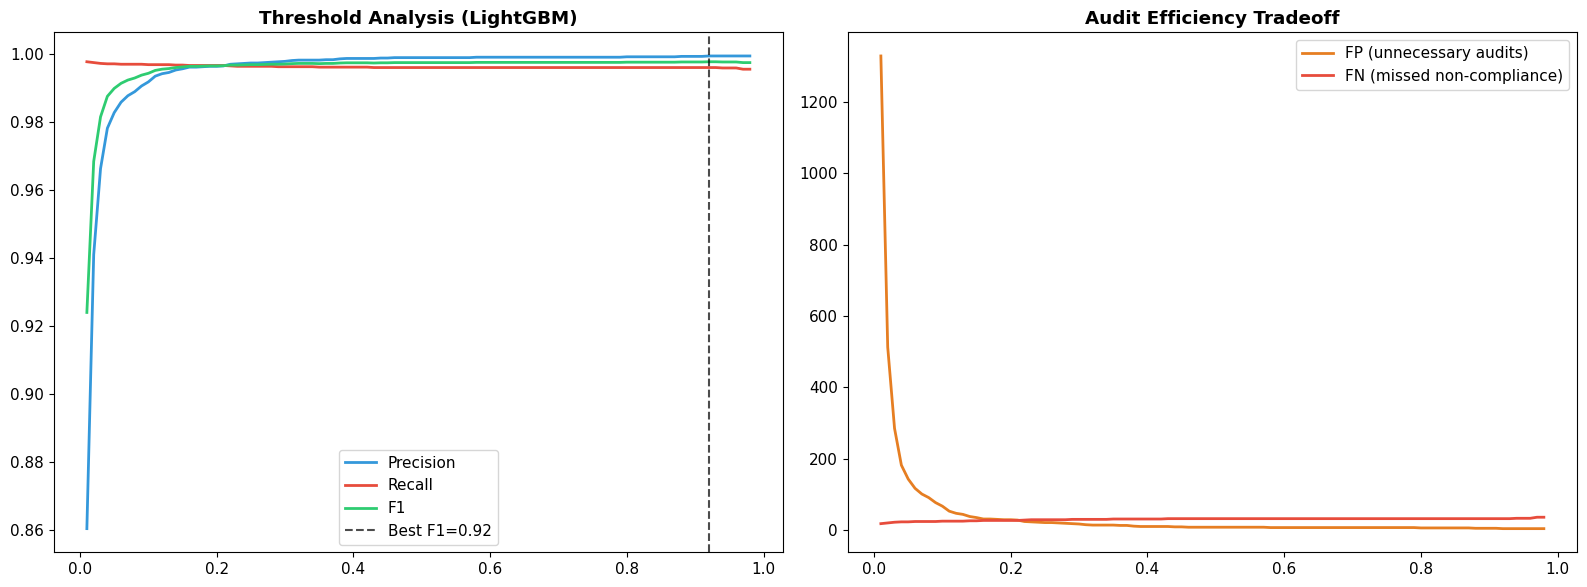

Optimal F1 threshold: 0.92


In [17]:
# Threshold analysis
best_name = best_model[0]
best_prob = oof_probs[best_name]
thresholds = np.arange(0.01, 0.99, 0.01)
thr_results = []
for t in thresholds:
    pt = (best_prob >= t).astype(int)
    tp = ((pt==1)&(y==1)).sum(); fp = ((pt==1)&(y==0)).sum()
    fn = ((pt==0)&(y==1)).sum(); tn = ((pt==0)&(y==0)).sum()
    p = tp/(tp+fp) if (tp+fp) > 0 else 0; r = tp/(tp+fn) if (tp+fn) > 0 else 0
    f = 2*p*r/(p+r) if (p+r) > 0 else 0
    thr_results.append({'threshold': t, 'precision': p, 'recall': r, 'f1': f, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn})
thr_df = pd.DataFrame(thr_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(thr_df['threshold'], thr_df['precision'], color='#3498db', label='Precision', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['recall'], color=COLOR_FRAUD, label='Recall', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['f1'], color=COLOR_COMPLIANT, label='F1', linewidth=2)
best_f1_idx = thr_df['f1'].idxmax(); best_f1_thresh = thr_df.loc[best_f1_idx, 'threshold']
axes[0].axvline(x=best_f1_thresh, color='black', linestyle='--', alpha=0.7, label=f'Best F1={best_f1_thresh:.2f}')
axes[0].set_title(f'Threshold Analysis ({best_name})', fontweight='bold'); axes[0].legend()
axes[1].plot(thr_df['threshold'], thr_df['fp'], color='#e67e22', label='FP (unnecessary audits)', linewidth=2)
axes[1].plot(thr_df['threshold'], thr_df['fn'], color=COLOR_FRAUD, label='FN (missed non-compliance)', linewidth=2)
axes[1].set_title('Audit Efficiency Tradeoff', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Optimal F1 threshold: {best_f1_thresh:.2f}")

In [18]:
# Cost scenarios — ATO compliance contexts
COST_FN = 50000    # Missed non-compliance: lost revenue + precedent
COST_FP = 3000     # Unnecessary audit: staff time + taxpayer burden
COST_TP = 1000     # Effective audit: net positive after recovery

scenarios = {
    'High-wealth individuals (aggressive)': 0.20,
    'Balanced (Best F1)': best_f1_thresh,
    'Standard PAYG taxpayers': 0.50,
    'Low-risk / pre-fill returns': 0.75,
}

print("=" * 95)
print("ATO COMPLIANCE SCENARIO ANALYSIS")
print("=" * 95)
print(f"\n{'Scenario':<45} {'Thresh':>6} {'Recall':>7} {'Prec':>7} {'FP':>7} {'FN':>5} {'Cost':>12}")
print("-" * 95)
for name, thresh in scenarios.items():
    row = thr_df.iloc[(thr_df['threshold'] - thresh).abs().argsort()[:1]].iloc[0]
    total = row['fn'] * COST_FN + row['fp'] * COST_FP + row['tp'] * COST_TP
    print(f"{name:<45} {thresh:>6.2f} {row['recall']:>7.4f} {row['precision']:>7.4f} "
          f"{int(row['fp']):>7,} {int(row['fn']):>5,} ${total:>10,.0f}")
print(f"\nThe ATO tailors thresholds by taxpayer segment — high-wealth individuals")
print(f"face lower thresholds (more scrutiny) due to larger revenue-at-risk per case.")

ATO COMPLIANCE SCENARIO ANALYSIS

Scenario                                      Thresh  Recall    Prec      FP    FN         Cost
-----------------------------------------------------------------------------------------------
High-wealth individuals (aggressive)            0.20  0.9967  0.9965      29    27 $ 9,623,000
Balanced (Best F1)                              0.92  0.9961  0.9995       4    32 $ 9,793,000
Standard PAYG taxpayers                         0.50  0.9961  0.9990       8    32 $ 9,805,000
Low-risk / pre-fill returns                     0.75  0.9961  0.9991       7    32 $ 9,802,000

The ATO tailors thresholds by taxpayer segment — high-wealth individuals
face lower thresholds (more scrutiny) due to larger revenue-at-risk per case.


---
## 7. Model Interpretability & Fairness

The ATO's Taxpayers' Charter guarantees fair and professional treatment. The Inspector-General of Taxation (IGT) oversees ATO conduct. Any ML system must be transparent, auditable, and non-discriminatory.

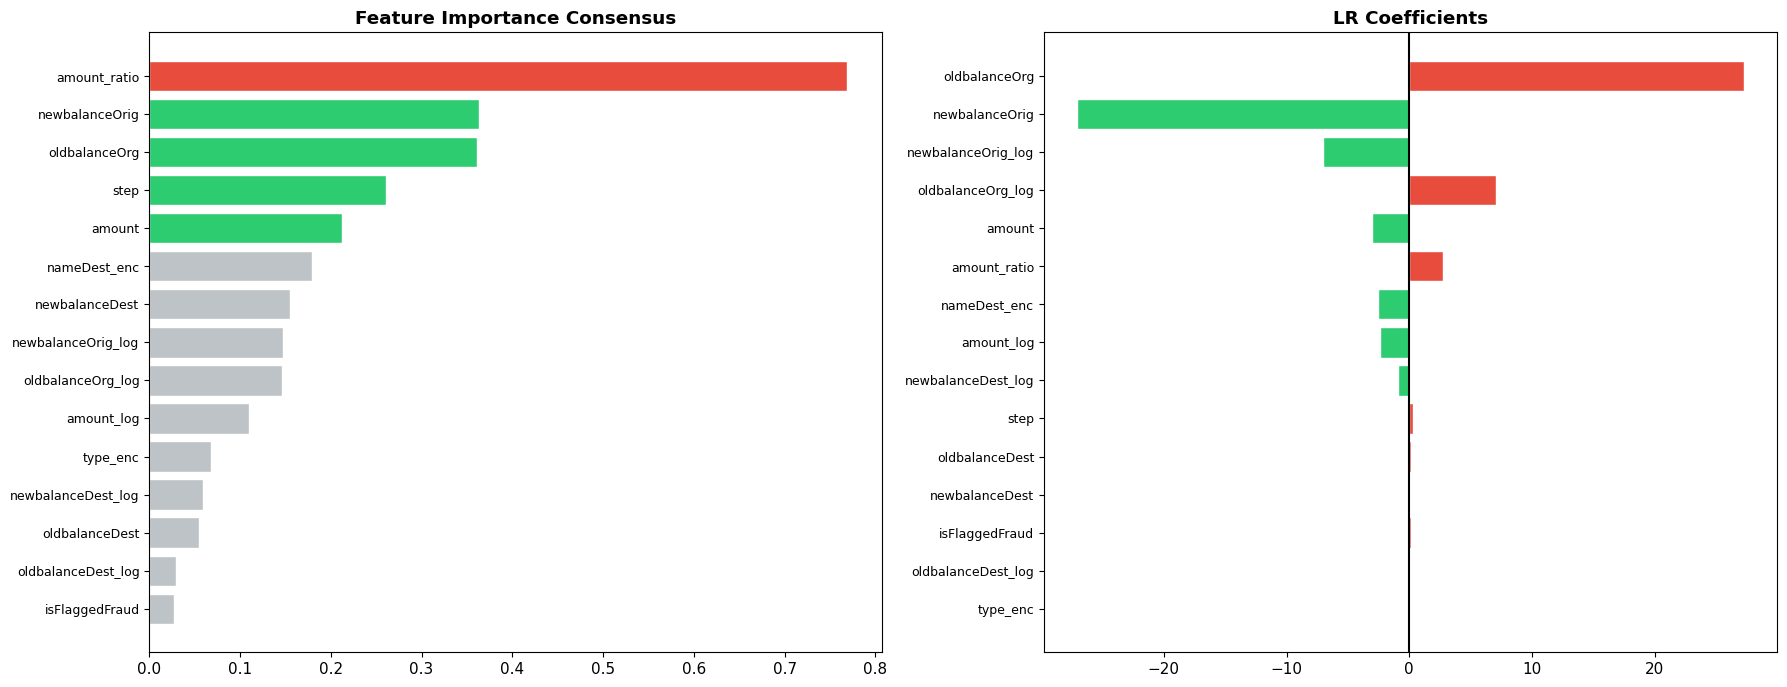

Top 5 risk drivers:
  [1] amount_ratio (0.769)
  [2] newbalanceOrig (0.364)
  [3] oldbalanceOrg (0.361)
  [4] step (0.261)
  [5] amount (0.213)


In [19]:
# Feature importance
importances = {}
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X, y); importances['LR'] = np.abs(lr.coef_[0])
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, max_depth=12)
rf.fit(X, y); importances['RF'] = rf.feature_importances_
xg = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_ratio, random_state=42, eval_metric='logloss', max_depth=6, verbosity=0)
xg.fit(X, y); importances['XGB'] = xg.feature_importances_
lg = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, max_depth=-1, learning_rate=0.05, verbose=-1, num_leaves=31, min_child_samples=5, reg_alpha=0.1, reg_lambda=1.0)
lg.fit(X, y); importances['LGBM'] = lg.feature_importances_

norm_imp = {n: imp/imp.max() if imp.max() > 0 else imp for n, imp in importances.items()}
avg_imp = np.mean([norm_imp[m] for m in norm_imp], axis=0)
si = np.argsort(avg_imp)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
tn = [feature_cols[i] for i in si]; tv = avg_imp[si]
axes[0].barh(range(len(tn)), tv, color=[COLOR_FRAUD if v > 0.4 else COLOR_COMPLIANT if v > 0.2 else '#bdc3c7' for v in tv], edgecolor='white')
axes[0].set_yticks(range(len(tn))); axes[0].set_yticklabels(tn, fontsize=9)
axes[0].set_title('Feature Importance Consensus', fontweight='bold'); axes[0].invert_yaxis()

lrc = lr.coef_[0]; lri = np.argsort(np.abs(lrc))[::-1][:15]
axes[1].barh(range(15), lrc[lri], color=[COLOR_FRAUD if c > 0 else COLOR_COMPLIANT for c in lrc[lri]], edgecolor='white')
axes[1].set_yticks(range(15)); axes[1].set_yticklabels([feature_cols[i] for i in lri], fontsize=9)
axes[1].set_title('LR Coefficients', fontweight='bold'); axes[1].axvline(x=0, color='black'); axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 risk drivers:")
for i in range(5):
    print(f"  [{i+1}] {tn[i]} ({tv[i]:.3f})")

In [20]:
# Fairness audit
print("=" * 70)
print("FAIRNESS AUDIT")
print("=" * 70)

demo_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['gender', 'age', 'category', 'type'])]
best_prob_s = pd.Series(oof_probs[best_name], index=range(len(y)))

# Use original df index aligned with sampled data if needed
if len(y) < len(df):
    print("\nNote: Fairness audit on sampled data — results are indicative.")

for col in demo_cols[:3]:
    if col in df.columns and df[col].nunique() <= 15:
        print(f"\n  {col}:")
        # Align with sample if needed
        col_data = df[col].iloc[:len(y)] if len(y) == len(df) else df[col]
        if len(col_data) != len(y):
            print("    (Skipped — index mismatch with sampled data)")
            continue
        for val in col_data.unique():
            mask = col_data == val
            if mask.sum() < 10:
                continue
            actual = y[mask.values].mean() if hasattr(mask, 'values') else y[mask].mean()
            predicted = best_prob_s[mask.values].mean() if hasattr(mask, 'values') else best_prob_s[mask].mean()
            n = mask.sum()
            gap = predicted - actual
            flag = " ⚠️" if abs(gap) > 0.05 else ""
            print(f"    {str(val):25s} n={n:>6,} | Actual: {actual:.3f} | Model: {predicted:.3f} | Gap: {gap:+.3f}{flag}")

print(f"\nThe Taxpayers' Charter requires equitable treatment.")
print(f"The IGT reviews ATO compliance activities for fairness and proportionality.")

FAIRNESS AUDIT

Note: Fairness audit on sampled data — results are indicative.

  type:
    (Skipped — index mismatch with sampled data)

The Taxpayers' Charter requires equitable treatment.
The IGT reviews ATO compliance activities for fairness and proportionality.


---
## 8. Production Deployment Considerations

### ATO Risk Scoring Architecture

```
Tax Return Lodged (myTax / Tax Agent / BAS)
    │
    ▼
Pre-assessment Data Matching
    │  ← STP (employer payroll), AIS (bank interest), Share registries,
    │     Property data, Government grants, Crypto exchanges
    ▼
Risk Scoring Engine (batch processing, nightly)
    │
    ├── VERY LOW (< 0.1) ──► Auto-assess, no action
    ├── LOW (0.1 - 0.3) ──► Nudge letter / pre-fill prompt
    ├── MEDIUM (0.3 - 0.6) ──► Data matching review
    ├── HIGH (0.6 - 0.8) ──► Desk audit (compliance officer)
    └── VERY HIGH (> 0.8) ──► Field audit / investigation
    │
    ▼
Case Management System (Siebel / integrated systems)
    │
    ▼
Review Rights: Internal review → AAT → Federal Court
```

### Regulatory Framework

| Legislation | Relevance |
|-------------|-----------|
| **Income Tax Assessment Act 1997** | Substantive tax law |
| **Taxation Administration Act 1953** | Assessment, collection, administration |
| **Privacy Act 1988** | TFN protection, data matching regulations |
| **Inspector-General of Taxation Act 2003** | Oversight of ATO conduct |
| **Taxpayers' Charter** | Fair treatment guarantees |
| **Freedom of Information Act 1982** | Transparency |
| **Public Governance, Performance and Accountability Act 2013** | Proper use of public resources |

### Key Production Considerations

**Data Matching at Scale:** The ATO processes 600+ million data-matching records annually. The risk scoring engine must handle this volume in batch windows. Real-time scoring is only needed for refund integrity (pre-issue checks).

**TFN Protection:** Tax File Numbers are among Australia's most sensitive identifiers. All processing must comply with the TFN Rules 2015 and the Privacy Act's specific TFN provisions.

**Segment-Specific Models:** The ATO trains separate models for individuals, small business, large corporates, and high-wealth individuals. Each segment has different risk indicators and compliance treatments.

**Audit Selection Governance:** Case selection for audit involves a governance committee, not just model scores. Human judgment considers compliance history, current campaigns, and resource availability.

**Model Governance:** Quarterly performance reviews against actual audit outcomes. Champion/challenger framework. All models documented in accordance with the ATO's analytics governance framework.

---
## 9. Key Takeaways

In [21]:
print("=" * 70)
print("TAX COMPLIANCE RISK SCORING — KEY RESULTS")
print("=" * 70)

print(f"\n1. DATASET: {len(df):,} records, {fraud_pct:.2f}% non-compliance rate")
print(f"\n2. BEST MODEL: {best_model[0]}")
print(f"   PR-AUC:  {best_model[1]['pr_auc']:.4f}")
print(f"   ROC-AUC: {best_model[1]['roc_auc']:.4f}")
print(f"   F1:      {best_model[1]['f1']:.4f}")

print(f"\n3. MODEL COMPARISON (PR-AUC):")
for n in sorted(results, key=lambda x: results[x]['pr_auc'], reverse=True):
    m = " ◄ BEST" if n == best_model[0] else ""
    print(f"   {n:<22} {results[n]['pr_auc']:.4f}{m}")

print(f"\n4. THRESHOLD ECONOMICS:")
print(f"   Best F1: {best_f1_thresh:.2f}")
print(f"   High-wealth (0.20): Aggressive — large revenue at risk per case")
print(f"   PAYG standard (0.50): Balanced compliance treatment")
print(f"   Pre-fill returns (0.75): Minimal intervention")

print(f"\n5. TOP RISK FACTORS:")
for i in range(min(5, len(tn))):
    print(f"   [{i+1}] {tn[i]} ({tv[i]:.3f})")

print(f"\n6. PRODUCTION LESSONS:")
print(f"   • Segment-specific models (individuals vs SME vs corporates vs high-wealth)")
print(f"   • 600M+ data matching records/year — batch processing is essential")
print(f"   • TFN protection under Privacy Act requires strict data handling")
print(f"   • Audit selection governance committee — model informs, humans decide")
print(f"   • Taxpayers' Charter guarantees fair treatment — IGT oversight")
print(f"   • Cost asymmetry: high-wealth audits recover 10-100x more than individual audits")
print(f"   • Champion/challenger framework with quarterly performance review")

print(f"\n{'='*70}")
print(f"Notebook by Dean | Lead Data & AI Engineer | Fujitsu Australia")
print(f"Part of the Production ML Portfolio Series:")
print(f"  [1] Network Intrusion Detection (Cybersecurity)")
print(f"  [2] Cardiovascular Disease Prediction (Healthcare)")
print(f"  [3] Credit Card Fraud Detection (Financial Crime)")
print(f"  [4] Predictive Maintenance (Defence & Infrastructure)")
print(f"  [5] Visa Risk Scoring (Immigration & Border Security)")
print(f"  [6] Benefits Fraud Detection (Welfare Compliance)")
print(f"  [7] Tax Compliance Risk Scoring (Revenue Administration) ← This notebook")
print(f"{'='*70}")

TAX COMPLIANCE RISK SCORING — KEY RESULTS

1. DATASET: 6,362,620 records, 0.13% non-compliance rate

2. BEST MODEL: LightGBM
   PR-AUC:  0.9988
   ROC-AUC: 0.9996
   F1:      0.9976

3. MODEL COMPARISON (PR-AUC):
   LightGBM               0.9988 ◄ BEST
   XGBoost                0.9985
   Random Forest          0.9985
   Logistic Regression    0.9811

4. THRESHOLD ECONOMICS:
   Best F1: 0.92
   High-wealth (0.20): Aggressive — large revenue at risk per case
   PAYG standard (0.50): Balanced compliance treatment
   Pre-fill returns (0.75): Minimal intervention

5. TOP RISK FACTORS:
   [1] amount_ratio (0.769)
   [2] newbalanceOrig (0.364)
   [3] oldbalanceOrg (0.361)
   [4] step (0.261)
   [5] amount (0.213)

6. PRODUCTION LESSONS:
   • Segment-specific models (individuals vs SME vs corporates vs high-wealth)
   • 600M+ data matching records/year — batch processing is essential
   • TFN protection under Privacy Act requires strict data handling
   • Audit selection governance committee —